In [1]:
import scipy as sp
import warnings
warnings.filterwarnings("ignore")
try: # Account for different module conventions in different versions of scipy
    from scipy.misc import derivative
except ImportError:
    from scipy.differentiate import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum
import torch
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity
from utils import hbar, c, alpha # Plank's constant in eV*s, speed of light in nanometers per second, fine structure constant
tau = 6.4*1e-13 # scattering time in seconds

### We first find the conductivity for CPA (TM modes) at large kR

In [2]:
M = 1000 # Number of sampled points
epsilon = 2.1 # Permittivity of the sphere
x_1 = 300
x_2 = 304
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon) # Refractive index
y = x * m # epsilonkR in the cylinder

In [3]:
l = 5
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [4]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_asymptotic = 1 + 1j*m*tan(y-l*pi/2)

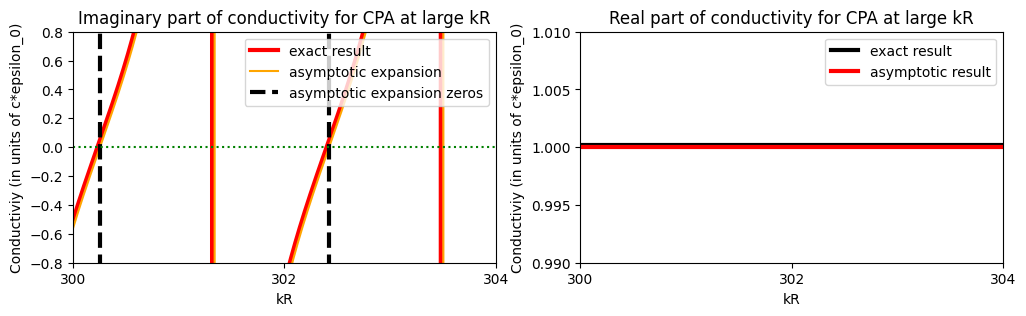

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax1.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax1.set_ylim(-0.8, 0.8)
ax1.vlines([pi/2/m]+ pi * linspace(1, 10000, 10000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax1.set_xlim(x_1, x_2);
ax1.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax1.set_xlabel("kR")
ax1.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax1.set_title("Imaginary part of conductivity for CPA at large kR");
ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.legend(loc = "best");

ax2.plot(x, sigmas[0, :], color="black", linewidth=3, label="exact result")
ax2.plot(x, sigmas_asymptotic.real, color="red", linewidth=3, label="asymptotic result")
ax2.set_xlim(x_1, x_2);
ax2.set_ylim(0.99, 1.01)
ax2.set_xlabel("kR")
ax2.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax2.set_title("Real part of conductivity for CPA at large kR");
ax2.legend()
ax2.set_xticks([x_1, (x_1+x_2)/2, x_2]);
#plt.savefig("./paper/large_kr_cpa.pdf")

### We verify that the above does indeed correspond to CPA

In [6]:
s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])/x))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  3.6696083277916142e-25


### Now we look at subwavelength coherent perfect absorption

In [7]:
M = 10000
epsilon = 2.1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

ls = np.array([1, 2, 3])
sigma_real_l = np.zeros((len(ls), len(x)))
sigma_imaginary_l = np.zeros((len(ls), len(x)))
quasistatic_dispersion_l = np.zeros((len(ls), len(x)))

for (l_idx, l) in enumerate(ls):
    print("Angular momentum (l): ", l)
    j_ly = spherical_jn(l, y)
    j_lx = spherical_jn(l, x)
    y_lx = spherical_yn(l, x)
    
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
    xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
    xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)
    
    prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
    mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
    vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

    sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
    sigma_real = sigmas[0, :]
    sigma_imaginary = sigmas[1, :]
    # The quasistatic dispersion (from the plasmon dispersion)
    quasistatic_dispersion = x*(l*epsilon+(l+1))/(l*(l+1))
    sigma_real_l[l_idx, :] = sigma_real
    sigma_imaginary_l[l_idx, :] = sigma_imaginary
    quasistatic_dispersion_l[l_idx, :] = quasistatic_dispersion

Angular momentum (l):  1
Angular momentum (l):  2
Angular momentum (l):  3


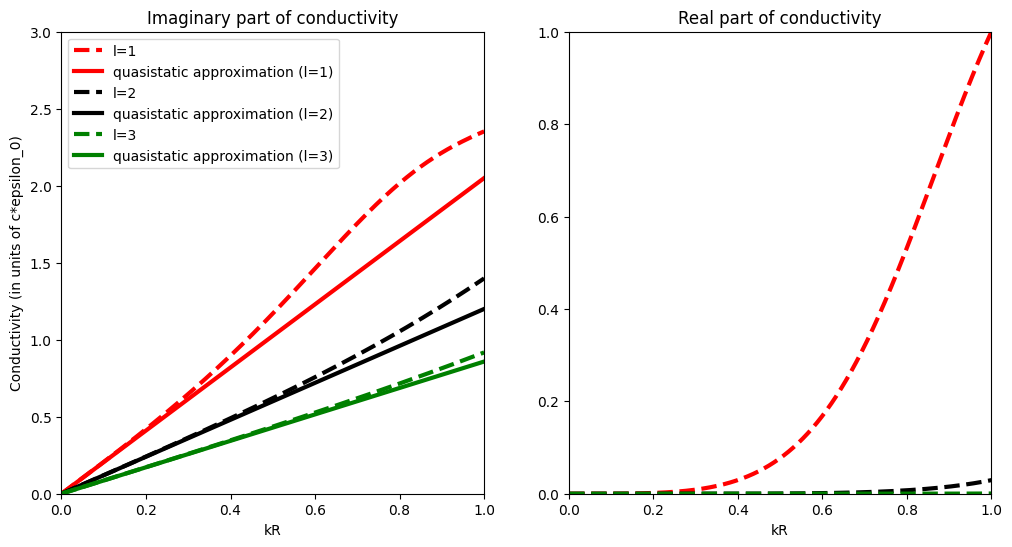

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

l_colors = ["red", "black", "green"]
for (l_idx, l) in enumerate(ls):
    color = l_colors[l_idx]
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    quasistatic_dispersion = quasistatic_dispersion_l[l_idx]

    ax1.plot(x, sigma_imaginary, label=f"l={l}", color=color, linestyle="dashed", linewidth=3)
    ax1.plot(x, quasistatic_dispersion, label=f"quasistatic approximation (l={l})", color=color, linestyle="solid", linewidth=3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 3)
    ax1.set_title("Imaginary part of conductivity")
    ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
    ax1.set_xlabel("kR");
    ax1.legend();
    
    ax2.plot(x, sigma_real, label=f"l={l}", color=color, linestyle="dashed", linewidth=3)    
    ax2.set_ylim(0, 1)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("kR");
    ax2.set_title("Real part of conductivity");
    plt.savefig("./paper/closed_form_cpa_solution.pdf")
    #plt.savefig("./cleo_2026/closed_form_cpa_solution.pdf")

### We verify that the above conductivity profile corresponds to CPA. Note that due to the very small values for $kR<<1$, we run into some numerical errors, so we restrict the range over which we verify the validity of our approach. 

In [9]:
x_min = 0.05
x_min_idx = np.argmin(np.abs(x-x_min))
for (l_idx, l) in enumerate(ls):
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigma_real + 1j*sigma_imaginary)/x))**2
    tm_numerator = abs(e_r_cpa_numerator(l, x, epsilon, 1j*(sigma_real + 1j*sigma_imaginary)/x))

    print("Maximum value for |s|^2: ", s_sqrds[x_min_idx:].max())
    print("Maximum (absolute) value for the cpa numerator", tm_numerator[x_min_idx:].max(), "\n")

Maximum value for |s|^2:  2.5714878244928012e-23
Maximum (absolute) value for the cpa numerator 2.842170979519066e-14 

Maximum value for |s|^2:  7.645066015181355e-16
Maximum (absolute) value for the cpa numerator 3.5527136788005016e-14 

Maximum value for |s|^2:  2.1344394878349228e-07
Maximum (absolute) value for the cpa numerator 4.263256414560601e-14 



In [10]:
# find the fermi energies, radii and angular frequencies for l = 1: 
l_idx = 0
sigma_imaginary = sigma_imaginary_l[l_idx]
sigma_real = sigma_real_l[l_idx]

E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau)

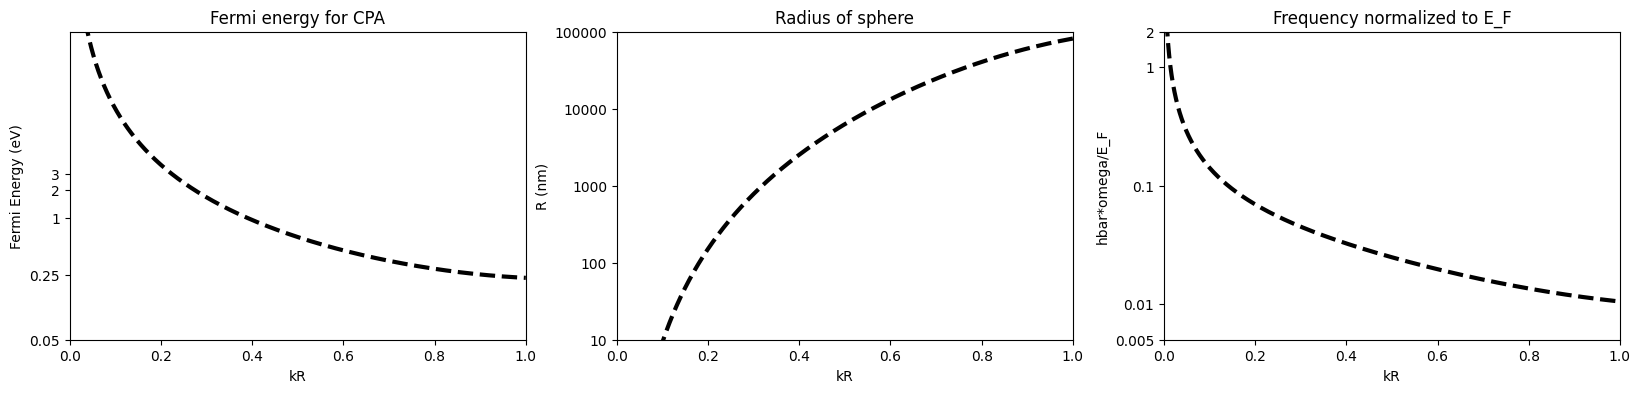

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))
ax1.plot(x, log(E_F), color="black", linestyle="dashed", linewidth=3)
ax1.set_yticks([log(0.05), log(0.25), log(1), log(2), log(3)], [0.05, 0.25, 1, 2, 3])
ax1.set_ylim(log(0.05), log(100));
ax1.set_xlim(0, 1)
ax1.set_xlabel("kR");
ax1.set_ylabel("Fermi Energy (eV)");
ax1.set_title("Fermi energy for CPA");
#ax1.set_aspect('equal')

ax2.plot(x, log(a), color="black", linestyle="dashed", linewidth=3)
ax2.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
ax2.set_ylim(log(1e1), log(1e5));
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_ylabel("R (nm)");
ax2.set_title("Radius of sphere");
#ax2.set_aspect('equal')

ax3.plot(x, log(hbar_omega/E_F), color="black", linestyle="dashed", linewidth=3)
ax3.set_yticks([log(0.005), log(0.01), log(0.1), log(1), log(2)], [0.005, 0.01, 0.1, 1, 2])
ax3.set_ylim(log(0.005), log(2));
ax3.set_xlim(0, 1)
ax3.set_xlabel("kR");
ax3.set_ylabel("hbar*omega/E_F");
ax3.set_title("Frequency normalized to E_F");
#ax3.set_aspect('equal')

#plt.savefig("./cleo_2026/graphene_closed_form_cpa.pdf")

### We verify that the above Fermi energies/radii correspond to the CPA conductivities

In [12]:
omega = c*x/a
graphene_cpa_sigmas = graphene_conductivity(E_F, omega*hbar, hbar/tau, include_interband=False)
#graphene_cpa_sigmas = graphene_conductivity(E_F, omega*hbar, hbar/tau, include_interband=True)
print("Maximum deviation from CPA conductivity (in normalized absolute value): ", abs((graphene_cpa_sigmas - sigma_real - 1j*sigma_imaginary)/graphene_cpa_sigmas).max())

Maximum deviation from CPA conductivity (in normalized absolute value):  6.756257613172948e-16


### Now we calculate the bandwidth for CPA

In [18]:
idxs = [3000, 4000, 5000, 6000, 7000, 8000, 9000]
M = int(1e5)
omega_range = linspace(0.1, 300, M)*1e12 # frequency range we examine (in Hertz)
s_sqrds = zeros((len(idxs), M))
s_sqrds_approximate = zeros((len(idxs), M)) # sqrds from an analytic formula

l = 1
for (sq_idx, idx) in enumerate(idxs):
    x_range = omega_range * a[idx]/c # keep radius fixed
    sigma_range = graphene_conductivity(E_F[idx], omega_range*hbar, hbar/tau, include_interband=False)
    g_omega_range = sigma_range*1j/x_range
    s_sqrds[sq_idx, :] = abs(e_r_cpa(l, x_range, epsilon, g_omega_range))**2
    s_sqrds_approximate[sq_idx, :] = 1 - (4*x[idx]**6)/((4*x[idx]**6)+(2+epsilon)**2*(1-omega_range*hbar/hbar_omega[idx])**2)

In [19]:
print("Minimum |s|^2 for each index: ", s_sqrds.min((1)))

Minimum |s|^2 for each index:  [5.31563826e-07 2.40714638e-07 1.12873103e-07 9.55459983e-07
 1.09776070e-06 1.03679138e-06 1.77158877e-08]


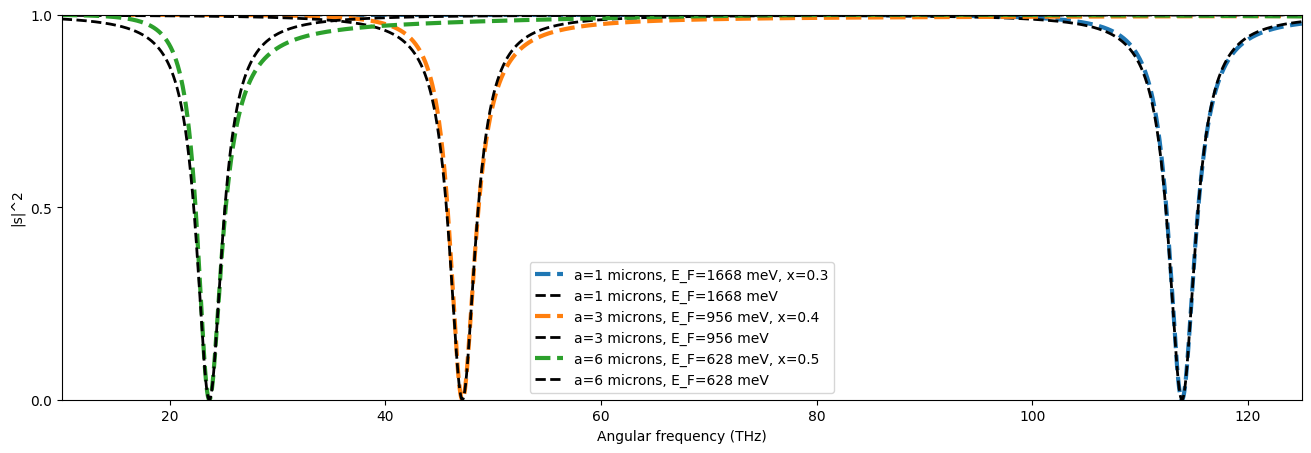

In [49]:
fig, ax = plt.subplots(figsize=(16, 5))
for (sq_idx, idx) in enumerate(idxs[0:3]):
    ax.plot(omega_range/1e12, s_sqrds[sq_idx], linestyle="dashed", linewidth=3, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV, x={round(x[idx], 2)}")
    ax.plot(omega_range/1e12, s_sqrds_approximate[sq_idx], linestyle="dashed", color="black", linewidth=2, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])
ax.set_xlim(10, 125);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");
ax.legend();
plt.savefig("./paper/approximate_ssquared.pdf")
#plt.savefig("./cleo_2026/graphene_bandwidth.pdf")

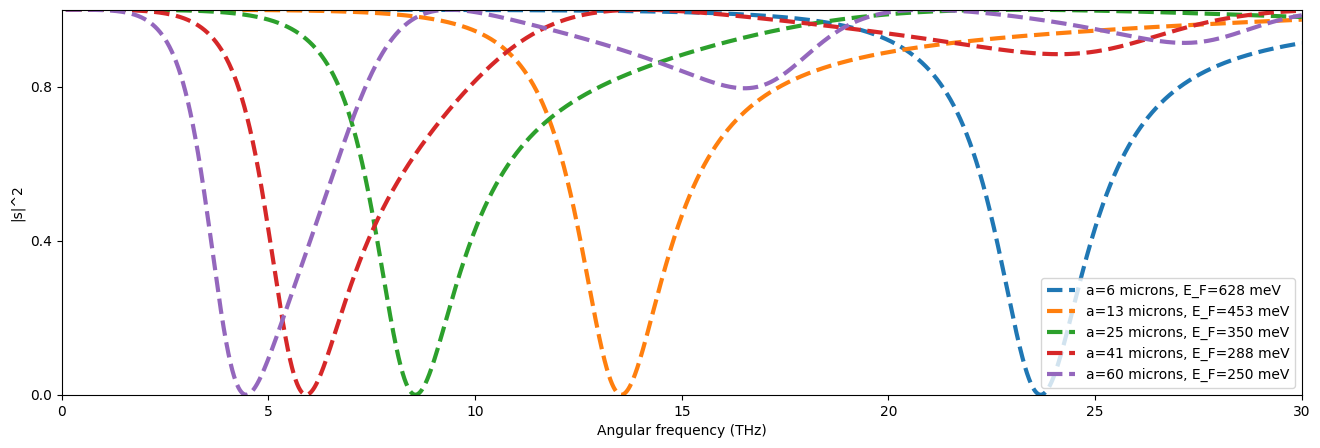

In [48]:
fig, ax = plt.subplots(figsize=(16, 5))
for (sq_idx, idx) in enumerate(idxs):
    if sq_idx < 2:
        continue
    ax.plot(omega_range/1e12, s_sqrds[sq_idx], linestyle="dashed", linewidth=3, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.4, 0.8])
ax.set_xlim(0, 30);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");
ax.legend();
#plt.savefig("./paper/bandwidth.pdf")
#plt.savefig("./cleo_2026/graphene_bandwidth.pdf")

### Transverse Electric modes. We first look at large $kR$

In [8]:
M = 1000
epsilon = 2.1
x_1 = 300
x_2 = 305
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [9]:
l = 7
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
small_sphere_dispersion = -(2*l+1)/x

sigmas_asymptotic = 1 - 1j*m*1/tan(y-l*pi/2)

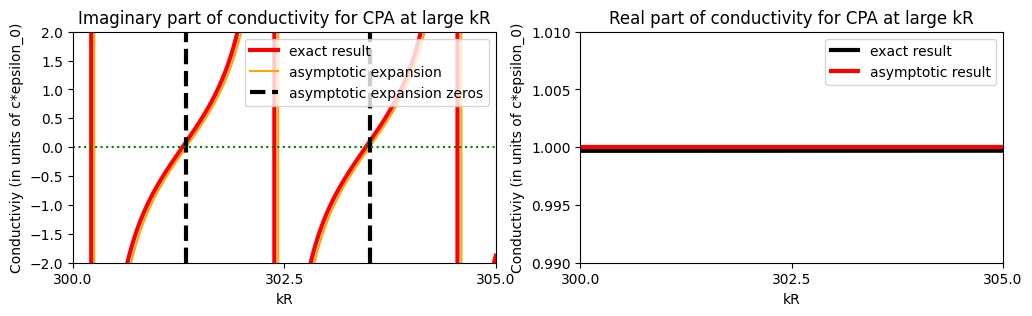

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(x, sigma_imaginary, color="red", linewidth=3, label="exact result")
ax1.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax1.set_ylim(-2, 2)
ax1.vlines([pi/m]+ pi * linspace(1, 10000, 10000)/m, -2, 2, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax1.set_xlim(x_1, x_2);
ax1.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax1.set_xlabel("kR")
ax1.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax1.set_title("Imaginary part of conductivity for CPA at large kR");
ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.legend(loc = "best");

ax2.plot(x, sigma_real , color="black", linewidth=3, label="exact result")
ax2.plot(x, sigmas_asymptotic.real, color="red", linewidth=3, label="asymptotic result")
ax2.set_xlim(x_1, x_2);
ax2.set_ylim(0.99, 1.01)
ax2.set_xlabel("kR")
ax2.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax2.set_title("Real part of conductivity for CPA at large kR");
ax2.legend()
ax2.set_xticks([x_1, (x_1+x_2)/2, x_2]);
plt.savefig("./paper/large_kr_cpa_magnetic.pdf");

In [11]:
s_sqrds = abs(h_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])*x))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  3.28067585887975e-27


In [120]:
M = 1000
epsilon = 12
x_1 = 1e-3
x_2 = 0.09
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = (1/x)/(j_ly*(j_lx**2+y_lx**2))
mat = np.array([[y_lx, j_lx], [-j_lx , y_lx]])
vec = np.array([j_lx*yjl_prime-xjl_prime*j_ly, j_ly*xyl_prime-y_lx*yjl_prime])

In [121]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]
small_sphere_dispersion = -(2*l+1)/x

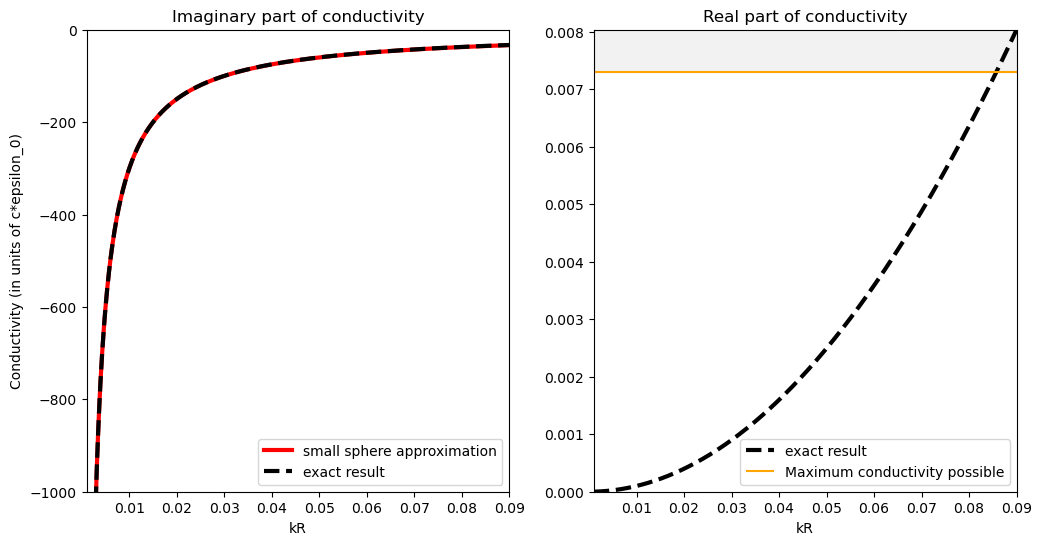

In [122]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_sphere_dispersion, label="small sphere approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_ylim(-1000, 0)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.set_ylim(0, )
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.legend();

### We check that the above indeed corresponds to CPA

In [123]:
s_sqrds = abs(h_r_cpa(l, x, epsilon, 1j*(sigmas[0, :] + 1j*sigmas[1, :])*x))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  3.877422304555238e-14


### We now find the Fermi energies and radii corresponding to CPA

In [124]:
E_F_1 = (hbar/tau)*(alpha+sqrt(alpha**2-sigma_real**2))/(2*sigma_real);
E_F_2 = (hbar/tau)*(alpha-sqrt(alpha**2-sigma_real**2))/(2*sigma_real);

a_1 = c*x*hbar/(2*E_F_1);
a_2 = c*x*hbar/(2*E_F_2);

### We verify that the Fermi energies/radii give us the correct real part of the conductivity 

In [125]:
for (a, E_F) in zip([a_1, a_2], [E_F_1, E_F_2]):
    omega = c*x/a
    graphene_cpa_sigmas = (4*1j*alpha*E_F/(hbar*(omega+1j/tau))).real
    sigma_deviations =  abs((graphene_cpa_sigmas - sigma_real)/graphene_cpa_sigmas)
    sigma_deviations = np.where(np.isnan(sigma_deviations), 0, sigma_deviations)
    print("Maximum deviation from CPA conductivity (in normalized absolute value): ", sigma_deviations.max())

Maximum deviation from CPA conductivity (in normalized absolute value):  6.268468166667832e-16
Maximum deviation from CPA conductivity (in normalized absolute value):  6.155487159417475e-09


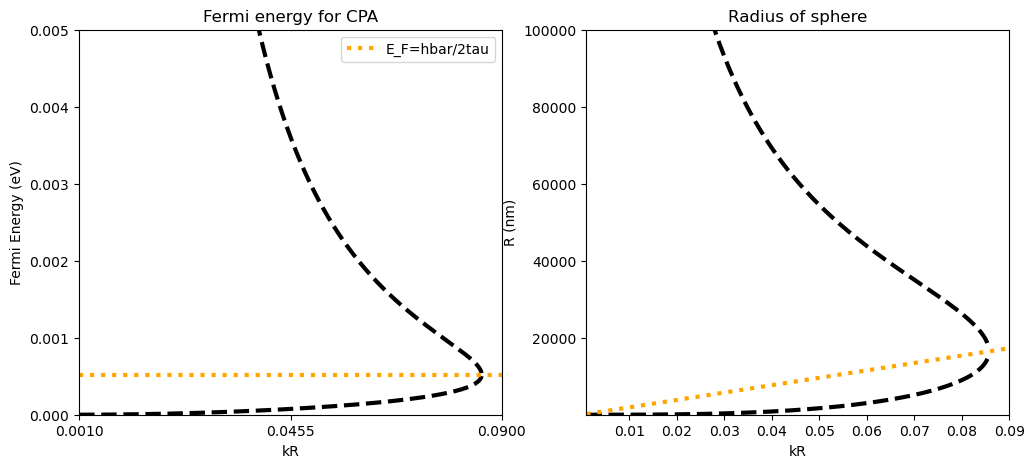

In [135]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(x, E_F_1, color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, E_F_2, color="black", linestyle="dashed", linewidth=3)

ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.set_xlim(x_1, x_2)
ax1.set_ylim(0, 0.005)
ax1.set_xlabel("kR");
ax1.set_ylabel("Fermi Energy (eV)");
ax1.hlines([hbar/(2*tau)], x_1, x_2, linestyle="dotted", color="orange", linewidth = 3, label="E_F=hbar/2tau")
ax1.legend()
ax1.set_title("Fermi energy for CPA");

ax2.plot(x, a_1, color="black", linestyle="dashed", linewidth=3)
ax2.plot(x, a_2, color="black", linestyle="dashed", linewidth=3)
ax2.plot(x, c*tau*x, color="orange", linestyle="dotted", linewidth=3, label="c*tau*x")
ax2.set_xlim(x_1, x_2)
ax2.set_ylim(10, 100000)
ax2.set_xlabel("kR");
ax2.set_ylabel("R (nm)");
ax2.set_title("Radius of sphere");
ax2.set_xlim(x_1, x_2);